## Task 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import re


len R = 208787
len t = 208787
Ns = 100


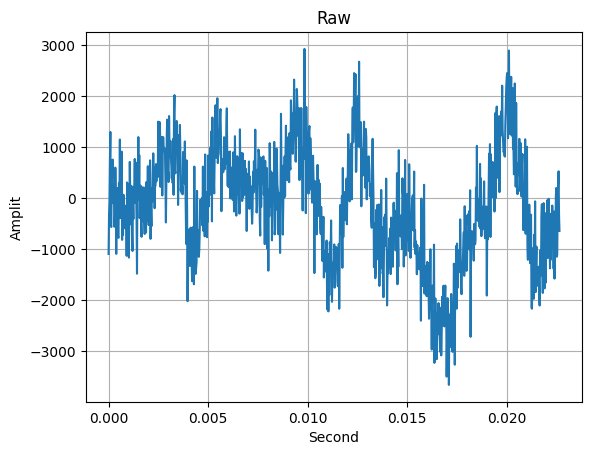

In [2]:

fs = 44100
fc = 4000
Ts = 0.0022676
Ns = int(round(fs * Ts))

data = sio.loadmat("Signals_task2/Signal3.mat")
R = np.ravel(data["R"])
t = np.ravel(data["t"])

print("len R =", len(R))
print("len t =", len(t))
print("Ns =", Ns)

plt.plot(t[:1000], R[:1000])
plt.title("Raw")
plt.xlabel("Second")
plt.ylabel("Amplit")
plt.grid()
plt.show()


## Down conversion

Best timing offset: 38
nbr of samples: 2089


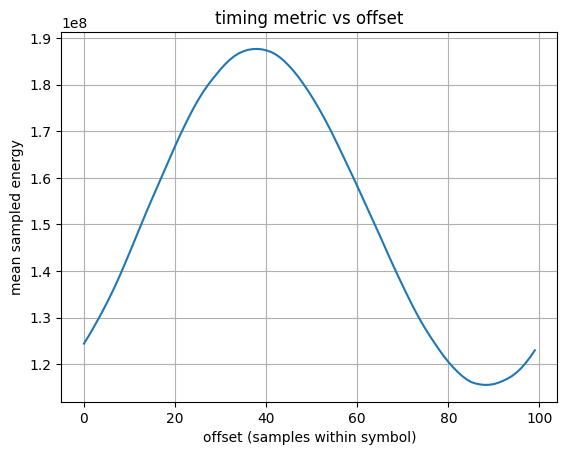

In [3]:
# downconvert to complex
n = np.arange(len(R))
r_bb = 2 * R * np.exp(-1j * 2 * np.pi * fc * n / fs)

# half-cycle sinus pulse
t_pulse = np.arange(Ns) / fs
p = np.sin(np.pi * t_pulse / Ts)

# matched filter
y = np.convolve(r_bb, p[::-1], mode="full")

# Try possible offsets inside one symbol
timing_metric = np.array([np.mean(np.abs(y[o::Ns])**2) for o in range(Ns)])
best_offset = int(np.argmax(timing_metric))

z_all = y[best_offset::Ns]

print("Best timing offset:", best_offset)
print("nbr of samples:", len(z_all))

plt.plot(timing_metric)
plt.title("timing metric vs offset")
plt.xlabel("offset (samples within symbol)")
plt.ylabel("mean sampled energy")
plt.grid()
plt.show()

## Frame alignment with pilots
- Find start and end of payload

Pilot fit score: 0.027903553979940952
Start pilot index: 13
End pilot index: 2066
Payload symbols: 2052
First pilot after norm: (2+2j)
Last pilot after norm:  (1.972137499685013+2.0015130766367983j)


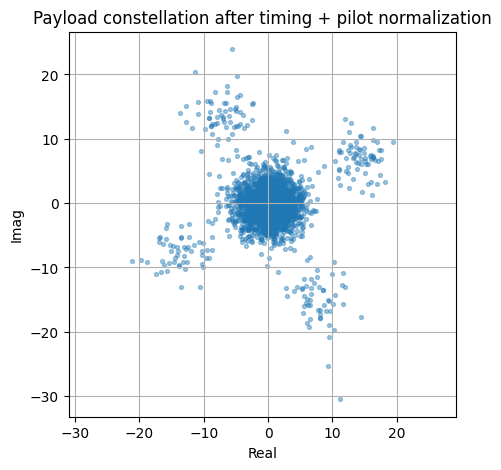

In [4]:
pilot = 2 + 2j

z = z_all[2:-2]

# Search for pilot
head_search = min(120, len(z) // 3)
tail_search = min(120, len(z) // 3)

best = None
for i_start in range(head_search):
    c_hat = z[i_start] / pilot

    # End pilot should be near tail
    j_min = max(i_start + 2, len(z) - tail_search)
    for i_end in range(j_min, len(z)):
        score = np.abs(z[i_end] / c_hat - pilot)
        if best is None or score < best[0]:
            best = (score, i_start, i_end, c_hat)

score, i_start, i_end, c_hat = best

# payload between start&end pilot
z_payload = z[i_start + 1:i_end]

z_payload_norm = z_payload / c_hat

print("Pilot fit score:", float(score))
print("Start pilot index:", i_start)
print("End pilot index:", i_end)
print("Payload symbols:", len(z_payload))
print("First pilot after norm:", z[i_start] / c_hat)
print("Last pilot after norm: ", z[i_end] / c_hat)

plt.figure(figsize=(5, 5))
plt.scatter(np.real(z_payload_norm), np.imag(z_payload_norm), s=8, alpha=0.4)
plt.title("Payload constellation after timing + pilot normalization")
plt.xlabel("Real")
plt.ylabel("Imag")
plt.axis("equal")
plt.grid()
plt.show()


In [5]:
def symbols_to_bits_qpsk(symbols):
    bits = np.empty(2 * len(symbols), dtype=np.uint8)
    bits[0::2] = (np.real(symbols) < 0).astype(np.uint8)  # first bit from I sign
    bits[1::2] = (np.imag(symbols) < 0).astype(np.uint8)  # second bit from Q sign
    return bits


def bits_to_ascii(bits):
    n_use = (len(bits) // 8) * 8
    bits = bits[:n_use]

    byte_vals = np.packbits(bits, bitorder="big")

    # non-printable shown is .
    chars = []
    printable_count = 0
    for b in byte_vals:
        if 32 <= b <= 126 or b in (9, 10, 13):
            chars.append(chr(int(b)))
            printable_count += 1
        else:
            chars.append(".")
    text = "".join(chars)

    printable_ratio = printable_count / len(byte_vals) if len(byte_vals) else 0.0
    return byte_vals, text, printable_ratio

In [6]:
candidates = []
base = z_payload_norm

for use_conj in [False, True]:
    z0 = np.conj(base) if use_conj else base
    for k in range(4):
        z_try = z0 * (1j ** k)  # 0, 90, 180, 270 degree rotations

        bits = symbols_to_bits_qpsk(z_try)
        byte_vals, text, printable_ratio = bits_to_ascii(bits)

        candidates.append({
            "use_conj": use_conj,
            "rot_k": k,
            "printable_ratio": printable_ratio,
            "bits": bits,
            "bytes": byte_vals,
            "text": text
        })

# Pick the most text-like candidate
best = max(candidates, key=lambda c: c["printable_ratio"])

print("Best hypothesis:")
print("  conjugate:", best["use_conj"])
print("  rotation k (90 deg steps):", best["rot_k"])
print("  printable ratio:", f"{best['printable_ratio']:.3f}")
print("  decoded bytes:", len(best["bytes"]))

print("\nDecoded text:\n")
print(best["text"][:1500])

# Optional: try to find lines containing "password"
hits = [line for line in best["text"].splitlines() if "password" in line.lower()]
if hits:
    print("\nPossible password lines:")
    for h in hits:
        print(h)

Best hypothesis:
  conjugate: True
  rotation k (90 deg steps): 0
  printable ratio: 0.413
  decoded bytes: 513

Decoded text:

&....2.+.N.c.V"u..J.+.h.v.CSf.....qB...Z...YL..#.....]...L.ha.6.Q**.l..........tv.+q4p......CB.*.HbQ$k&:,.k.8............NT..t.....U..abe/ I'..V +%.....n.A..].9...I0.h...
,O
